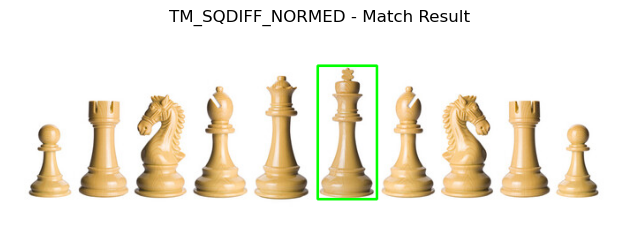

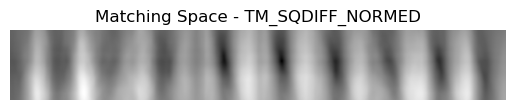

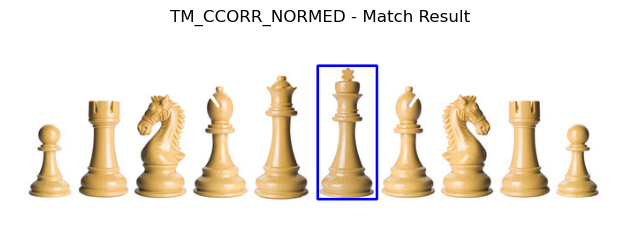

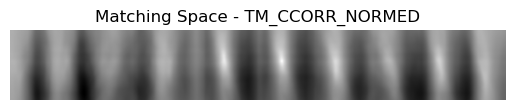

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, image):
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# 1. Load images
query_img = cv2.imread('images/Chess_Pieces.jpg')
template_img = cv2.imread('images/King.jpg')

# 2. Template Matching using TM_SQDIFF_NORMED
result_sqdiff = cv2.matchTemplate(query_img, template_img, cv2.TM_SQDIFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result_sqdiff)
top_left_sqdiff = min_loc
h, w = template_img.shape[:2]
bottom_right_sqdiff = (top_left_sqdiff[0] + w, top_left_sqdiff[1] + h)

# Draw rectangle and show results
matched_img_sqdiff = query_img.copy()
cv2.rectangle(matched_img_sqdiff, top_left_sqdiff, bottom_right_sqdiff, (0, 255, 0), 2)
show_image('TM_SQDIFF_NORMED - Match Result', matched_img_sqdiff)
plt.imshow(result_sqdiff, cmap='gray')
plt.title('Matching Space - TM_SQDIFF_NORMED')
plt.axis('off')
plt.show()

# 3. Template Matching using TM_CCORR_NORMED
result_ccorr = cv2.matchTemplate(query_img, template_img, cv2.TM_CCORR_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result_ccorr)
top_left_ccorr = max_loc
bottom_right_ccorr = (top_left_ccorr[0] + w, top_left_ccorr[1] + h)

# Draw rectangle and show results
matched_img_ccorr = query_img.copy()
cv2.rectangle(matched_img_ccorr, top_left_ccorr, bottom_right_ccorr, (255, 0, 0), 2)
show_image('TM_CCORR_NORMED - Match Result', matched_img_ccorr)
plt.imshow(result_ccorr, cmap='gray')
plt.title('Matching Space - TM_CCORR_NORMED')
plt.axis('off')
plt.show()

# 4. Explanation
# Comparison of TM_SQDIFF_NORMED vs TM_CCORR_NORMED:
# TM_SQDIFF_NORMED: Lower values indicate better matches. The best match is at the location with the minimum value.
# TM_CCORR_NORMED: Higher values indicate better matches. The best match is at the location with the maximum value.

#Matching space differences:
# TM_SQDIFF_NORMED produces a darker region where the match is best.
# TM_CCORR_NORMED produces a brighter region where the match is best.

#Each method has its strengths depending on the image contrast and noise. TM_CCORR_NORMED is generally more robust to lighting changes, while TM_SQDIFF_NORMED is sensitive to exact pixel differences.